### Week 9 — Model Optimization

#### Task
Improve model performance using:
- Hyperparameter TuniTg
- GridearchCV

### Deliverables

#### Model Performance Comparison

| Model | Before | After |
|---------|---------|---------|
| Model Name | Performance Score | Improved Score |

### Improvements
- Tuned model hyperparameters to achieve better performance.
- Used **GridSearchCV** to find the best parameter combination.
- Improved model accuracy and overall prediction quality.

## Skills Tested
- Model Optimization
- Hyperparameter Tuning
- GridSearchCV

### 1. Importing Libraries:


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

### 2. Loading The Dataset:

In [10]:
df = pd.read_csv('tickets_200.csv')
print(f"Dataset shape: {df.shape}")
print(f"Categories: {df['category'].nunique()}")
df['category'].value_counts()

Dataset shape: (200, 2)
Categories: 8


category
Upload issue         25
Login issue          25
Bug report           25
Permission issue     25
Payment issue        25
Network issue        25
Feature request      25
Performance issue    25
Name: count, dtype: int64

In [11]:
df.head()

,text,category
0,Upload keeps getting stuck at 90 percent,Upload issue
1,Incorrect username or password error,Login issue
2,Upload fails with server error 500,Upload issue
3,Settings not saving after change,Bug report
4,Permission error when opening file,Permission issue


### 3.Text Preprocessing:

In [12]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    # Tokenize and lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(token, pos='v') for token in tokens if token not in stopwords.words('english')]
    return ' '.join(tokens)

df['cleaned_text'] = df['text'].apply(clean_text)
df[['text', 'cleaned_text', 'category']].head()

,text,cleaned_text,category
0,Upload keeps getting stuck at 90 percent,upload keep get stick percent,Upload issue
1,Incorrect username or password error,incorrect username password error,Login issue
2,Upload fails with server error 500,upload fail server error,Upload issue
3,Settings not saving after change,settings save change,Bug report
4,Permission error when opening file,permission error open file,Permission issue


### 4. TF-IDF Vectorization:

In [13]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
X = vectorizer.fit_transform(df['cleaned_text'])
y = df['category']

print(f"Shape of feature matrix: {X.shape}")

Shape of feature matrix: (200, 179)


### 5. Train/Test Split:

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 150 samples
Test set size: 50 samples


### 6.Train The Model:

In [15]:
lr_model = LogisticRegression(max_iter=100)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, lr_pred)
print('Logistic Regression Accuracy (default hyperparameters):', baseline_accuracy)
print()
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy (default hyperparameters): 0.74

                   precision    recall  f1-score   support

       Bug report       0.43      0.50      0.46         6
  Feature request       1.00      0.83      0.91         6
      Login issue       1.00      0.67      0.80         6
    Network issue       0.71      0.83      0.77         6
    Payment issue       0.75      0.86      0.80         7
Performance issue       0.43      0.43      0.43         7
 Permission issue       0.86      1.00      0.92         6
     Upload issue       1.00      0.83      0.91         6

         accuracy                           0.74        50
        macro avg       0.77      0.74      0.75        50
     weighted avg       0.77      0.74      0.74        50



### 7.Model Optimization using GridSearchCV:

In [16]:
# Define hyperparameters to tune
param_grid = {
    'C': [0.01, 0.1, 1, 10, 50, 100],
    'solver': ['lbfgs', 'newton-cg'],
    'max_iter': [100, 200]
}

# Create GridSearchCV
grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring='accuracy')

# Fit the model
grid_search.fit(X_train, y_train)

# Get best parameters and score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.2f}")

# Evaluate on test set
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
print(f"Test accuracy with tuned model: {tuned_accuracy:.2f}")
print()
print(classification_report(y_test, y_pred_tuned))

Best parameters: {'C': 50, 'max_iter': 100, 'solver': 'lbfgs'}
Best cross-validation score: 0.83
Test accuracy with tuned model: 0.80

                   precision    recall  f1-score   support

       Bug report       0.50      0.33      0.40         6
  Feature request       1.00      0.83      0.91         6
      Login issue       1.00      0.67      0.80         6
    Network issue       0.86      1.00      0.92         6
    Payment issue       0.86      0.86      0.86         7
Performance issue       0.60      0.86      0.71         7
 Permission issue       0.86      1.00      0.92         6
     Upload issue       0.83      0.83      0.83         6

         accuracy                           0.80        50
        macro avg       0.81      0.80      0.79        50
     weighted avg       0.81      0.80      0.79        50



### 8. Before vs After Comparison:

In [17]:
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression'],
    'Before (default params)': [round(baseline_accuracy, 3)],
    'After (GridSearchCV tuned)': [round(tuned_accuracy, 3)],
    'Improvement': [round(tuned_accuracy - baseline_accuracy, 3)]
})
comparison_df

,Model,Before (default params),After (GridSearchCV tuned),Improvement
0,Logistic Regression,0.74,0.8,0.06


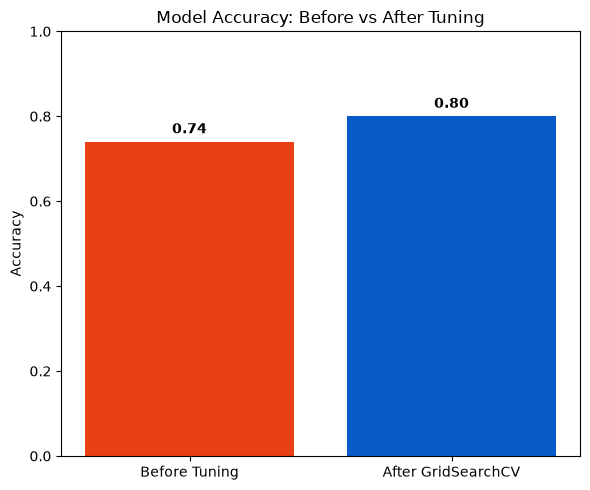

In [23]:
fig, ax = plt.subplots(figsize=(6, 5))

# Accuracy comparison bar chart
ax.bar(
    ['Before Tuning', 'After GridSearchCV'],
    [baseline_accuracy, tuned_accuracy],
    color=["#e94113", "#095bc7"]
)

ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy: Before vs After Tuning')

for i, v in enumerate([baseline_accuracy, tuned_accuracy]):
    ax.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()